# Knee Osteoarthritis — shared baseline pipeline

**Purpose:** a small, reusable end-to-end starting point for the project. This notebook installs dependencies with **uv**, reads severity-labeled X-ray images, trains a small CNN for **one epoch**, and calculates validation accuracy and multiclass AUROC.

**Before running:** supply the path to your dataset in **Section 2**. This notebook assumes an `ImageFolder`-style dataset: either one folder of grade subfolders (`0/`, `1/`, etc.), **or** existing `train/`, `val/`, and `test/` folders that each contain grade subfolders.

> This is a **technical smoke test**, not a clinical diagnostic system. It will not produce meaningful performance until you train and validate properly. **Do not evaluate on the test set during development.** If multiple images belong to one patient, create patient-level splits outside this notebook rather than its illustrative image-level splitting option.

## 1. Install packages and check the environment

Run the next two cells once per fresh Colab runtime. They use `uv` to install missing packages **into this notebook's current Python environment**, so imports work immediately. On a local machine, you can instead manage dependencies with `uv sync` and select that environment as your Jupyter kernel.

In [3]:
%pip -q install uv

/home/michael/Documents/GitHub/medical-image-classification/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [18]:
import importlib.util
import subprocess
import sys

required = {
    "torch": "torch",
    "torchvision": "torchvision",
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "PIL": "pillow",
    "tqdm": "tqdm",
}
missing = [package for module, package in required.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.run(["uv", "pip", "install", "--python", sys.executable, *missing], check=True)
else:
    print("All baseline dependencies are already installed.")
print("Notebook Python:", sys.executable)
print("If an import fails after installation, restart the runtime and rerun.")

All baseline dependencies are already installed.
Notebook Python: /home/michael/Documents/GitHub/medical-image-classification/.venv/bin/python
If an import fails after installation, restart the runtime and rerun.


In [19]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.14.0+cu130
Device: cpu


## 2. Configure data paths

**Colab:** mount your own Google Drive (a shared folder may need to be added as a shortcut to *My Drive*). **Local:** skip the mount cell and provide a local path. If you prefer, copy images from Drive to Colab's `/content/` storage to improve loading speed. Do not commit medical images to GitHub.

In [20]:
# On Colab only, uncomment and run:
# from google.colab import drive
# drive.mount('/content/drive')

# EDIT THIS PATH. Examples:
# '/content/drive/MyDrive/Knee_OA_Project/dataset'
# '/content/knee_oa_data'
# './data/knee_oa'
#DATA_DIR = Path('/content/drive/MyDrive/Knee_OA_Project/dataset')

# Optional: point to a Drive folder so checkpoints survive Colab disconnects.
#OUTPUT_DIR = Path('/content/drive/MyDrive/Knee_OA_Project/checkpoints')

# For testing the pipeline locally on a small subset use:
DATA_DIR = Path('../example_data')
OUTPUT_DIR = Path('../output')

# Input layout:
# A) dataset/0/*.png, dataset/1/*.png, ...
# B) dataset/train/0/*.png, dataset/val/0/*.png, dataset/test/0/*.png, ...
# Grade folder names can also be words such as Healthy, Doubtful, etc.
IMAGE_SIZE = 299
BATCH_SIZE = 16
NUM_WORKERS = 0   # portable default; try 2 in Colab after confirming it runs
EPOCHS = 1        # intentionally a smoke test
LR = 1e-3

if not DATA_DIR.exists():
    raise FileNotFoundError(f"Set DATA_DIR to your actual dataset folder first: {DATA_DIR}")
print('Dataset path:', DATA_DIR.resolve())

Dataset path: /home/michael/Documents/GitHub/medical-image-classification/example_data


## 3. Load and inspect data

The same label mapping and normalization will be used by every model. For fair comparison, **save and reuse the same split manifest** before individual experiments. If your data already comes with splits, this notebook respects them. If not, the fallback stratified image-level split below is for smoke-testing only and must be replaced when patients have multiple images.

The transform converts X-rays to **3-channel RGB** so this data pipeline also works with standard ImageNet-pretrained CNNs later.

In [21]:
from torchvision.datasets.folder import default_loader

# Normalization matches common ImageNet-pretrained ResNet/EfficientNet weights.
# Keep these choices the same in all experiments.
MEAN = (0.485, 0.456, 0.406)
STD = (0.229, 0.224, 0.225)

base_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

class ImageSubset(Dataset):
    """ImageFolder-compatible subset that stores explicit (path, label) entries."""
    def __init__(self, samples, transform):
        self.samples = [(str(p), int(y)) for p, y in samples]
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = default_loader(path)  # RGB
        return self.transform(img), label

existing_train = DATA_DIR / 'train'
existing_val = DATA_DIR / 'val'
existing_test = DATA_DIR / 'test'

if existing_train.is_dir() and existing_val.is_dir() and existing_test.is_dir():
    print('Using supplied train/val/test folders.')
    train_source = datasets.ImageFolder(existing_train)
    val_source = datasets.ImageFolder(existing_val)
    test_source = datasets.ImageFolder(existing_test)
    class_names = train_source.classes
    assert val_source.class_to_idx == train_source.class_to_idx == test_source.class_to_idx,         'Class folders do not match across splits.'
    split_samples = {
        'train': train_source.samples,
        'val': val_source.samples,
        'test': test_source.samples,
    }
else:
    print('No complete train/val/test layout found: creating illustrative image-level splits.')
    whole = datasets.ImageFolder(DATA_DIR)
    class_names = whole.classes
    paths = np.array([path for path, _ in whole.samples])
    labels = np.array([label for _, label in whole.samples])
    # 70% train / 15% val / 15% test, stratified by grade.
    ix = np.arange(len(paths))
    train_ix, remainder_ix = train_test_split(
        ix, test_size=0.30, random_state=SEED, stratify=labels)
    val_ix, test_ix = train_test_split(
        remainder_ix, test_size=0.50, random_state=SEED,
        stratify=labels[remainder_ix])
    split_samples = {
        'train': [(paths[i], labels[i]) for i in train_ix],
        'val': [(paths[i], labels[i]) for i in val_ix],
        'test': [(paths[i], labels[i]) for i in test_ix],
    }
    print('WARNING: image-level splitting is inappropriate if patients have multiple images.')

num_classes = len(class_names)
assert num_classes >= 2, 'At least two grade folders are required.'
print('Class mapping:', {name: i for i, name in enumerate(class_names)})
for split, entries in split_samples.items():
    print(f'{split}: {len(entries)} images')

# For shared reproducibility: export the same manifest to all members.
manifest = pd.DataFrame(
    [(split, str(path), int(label)) for split, entries in split_samples.items()
     for path, label in entries],
    columns=['split', 'path', 'label']
)
# Save to a shared persistent location AFTER confirming splits are appropriate.
# manifest.to_csv('/content/drive/MyDrive/Knee_OA_Project/split_manifest.csv', index=False)

datasets_by_split = {
    split: ImageSubset(samples, base_transform)
    for split, samples in split_samples.items()
}
loaders = {
    split: DataLoader(ds, batch_size=BATCH_SIZE, shuffle=(split == 'train'),
                      num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == 'cuda'))
    for split, ds in datasets_by_split.items()
}
images, labels = next(iter(loaders['train']))
print('One batch:', tuple(images.shape), 'Labels:', labels[:8].tolist())

No complete train/val/test layout found: creating illustrative image-level splits.
Class mapping: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}
train: 1068 images
val: 229 images
test: 229 images
One batch: (16, 3, 299, 299) Labels: [0, 0, 2, 1, 0, 1, 2, 0]


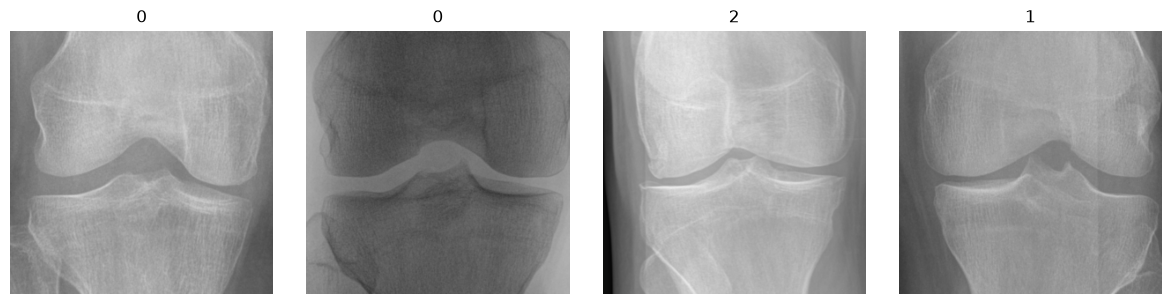

label    0    1    2    3   4
split                        
test    91   41   61   30   6
train  423  192  282  140  31
val     90   42   60   30   7


In [22]:
# Show several *unnormalized* examples; no training required.
fig, axes = plt.subplots(1, min(4, len(images)), figsize=(12, 3))
axes = np.atleast_1d(axes)
for ax, image, label in zip(axes, images, labels):
    display_image = image.permute(1, 2, 0).numpy() * np.array(STD) + np.array(MEAN)
    ax.imshow(display_image.clip(0, 1))
    ax.set_title(class_names[int(label)])
    ax.axis('off')
plt.tight_layout()
plt.show()

print(pd.crosstab(manifest['split'], manifest['label']).rename(
    columns={i: name for i, name in enumerate(class_names)}))

## 4. Minimal custom CNN

This deliberately simple baseline is only for validating the common pipeline. It will later be replaced or extended with an improved version. Its final layer outputs one **logit per grade**; no softmax is used before cross-entropy loss.

In [23]:
class TinyCNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Linear(64, n_classes)

    def forward(self, x):
        return self.classifier(self.features(x).flatten(1))

model = TinyCNN(num_classes).to(DEVICE)
with torch.no_grad():
    output = model(images[:2].to(DEVICE))
print('Output shape:', tuple(output.shape))
assert output.shape == (min(2, len(images)), num_classes)

Output shape: (2, 5)


## 5. Reusable training + validation loops

For the shared smoke test, **one epoch is sufficient**.

In [24]:
def run_epoch(model, loader, optimizer=None):
    is_training = optimizer is not None
    model.train(is_training)
    criterion = nn.CrossEntropyLoss()
    total_loss, correct, count = 0.0, 0, 0
    for x, y in tqdm(loader, leave=False, desc='train' if is_training else 'validate'):
        x, y = x.to(DEVICE), y.to(DEVICE)
        if is_training:
            optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(is_training):
            logits = model(x)
            loss = criterion(logits, y)
            if is_training:
                loss.backward()
                optimizer.step()
        total_loss += loss.item() * y.size(0)
        correct += (logits.argmax(dim=1) == y).sum().item()
        count += y.size(0)
    return {'loss': total_loss / count, 'accuracy': correct / count}

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
history = []
for epoch in range(EPOCHS):
    train_stats = run_epoch(model, loaders['train'], optimizer)
    val_stats = run_epoch(model, loaders['val'])
    history.append({'epoch': epoch + 1,
                    'train_loss': train_stats['loss'],
                    'train_accuracy': train_stats['accuracy'],
                    'val_loss': val_stats['loss'],
                    'val_accuracy': val_stats['accuracy']})
    print(history[-1])
pd.DataFrame(history)

{'epoch': 1, 'train_loss': 1.4417223858922608, 'train_accuracy': 0.3838951310861423, 'val_loss': 1.4322277666699939, 'val_accuracy': 0.3930131004366812}


,epoch,train_loss,train_accuracy,val_loss,val_accuracy
0,1,1.441722,0.383895,1.432228,0.393013


## 6. Validation predictions and metrics

For multiclass AUROC, use softmax probabilities and specify **one-vs-rest, macro average**. If validation contains no samples for a class, AUROC may be undefined; the function reports that rather than inventing a score.

**Do not evaluate the test split yet.** The shared team should agree on the final evaluation protocol first.

In [25]:
@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    actual, probs = [], []
    for x, y in loader:
        logits = model(x.to(DEVICE))
        actual.append(y.numpy())
        probs.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.concatenate(actual), np.concatenate(probs)

def summarize_metrics(y_true, probabilities, class_names):
    predictions = probabilities.argmax(axis=1)
    results = {'accuracy': accuracy_score(y_true, predictions)}
    present = np.unique(y_true)
    if len(class_names) == 2 and len(present) == 2:
        results['auroc'] = roc_auc_score(y_true, probabilities[:, 1])
    elif len(present) == len(class_names):
        results['auroc'] = roc_auc_score(
            y_true, probabilities, labels=np.arange(len(class_names)),
            multi_class='ovr', average='macro')
    else:
        results['auroc'] = float('nan')
        print('AUROC undefined: not all classes appear in this validation split.')
    return results, confusion_matrix(y_true, predictions,
                                      labels=np.arange(len(class_names)))

y_val, val_prob = get_predictions(model, loaders['val'])
metrics, cm = summarize_metrics(y_val, val_prob, class_names)
print('Validation metrics:', metrics)
print('Confusion matrix (rows=true, cols=predicted):')
display(pd.DataFrame(cm, index=class_names, columns=class_names))

Validation metrics: {'accuracy': 0.3930131004366812, 'auroc': 0.4588041269096845}
Confusion matrix (rows=true, cols=predicted):


,0,1,2,3,4
0,90,0,0,0,0
1,42,0,0,0,0
2,60,0,0,0,0
3,30,0,0,0,0
4,7,0,0,0,0


## 7. Optional: save a checkpoint

In Colab, **first mount Drive and set `OUTPUT_DIR` to your own writable Drive path**. Saving directly under `/content/` is temporary. Store large weights in Drive, not GitHub. Experiment settings belong alongside checkpoints.

In [ ]:
SAVE_CHECKPOINT = False  # Change to True once OUTPUT_DIR is configured.
if SAVE_CHECKPOINT:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    checkpoint_file = OUTPUT_DIR / 'tiny_cnn_smoke_test.pt'
    torch.save({
        'model_state_dict': model.state_dict(),
        'class_names': class_names,
        'image_size': IMAGE_SIZE,
        'normalization_mean': MEAN,
        'normalization_std': STD,
        'seed': SEED,
        'history': history,
    }, checkpoint_file)
    print('Saved:', checkpoint_file)
else:
    print('Checkpoint not saved; set SAVE_CHECKPOINT=True to enable.')